
📌 Explanation of Metrics and Interactive Components in the Dashboard Our dashboard provides a comprehensive analytical environment for exploring marketing campaign performance. Below are the key interactive elements and metrics, along with what they reveal:

🔹 1. Channel Filter This dropdown allows the user to view only campaigns from a selected marketing channel (e.g., Email, Social, Display). Purpose: Helps identify which channel performs best and when to invest more in specific platforms.

🔹 2. Objective Filter Allows filtering campaigns by their business purpose:

Acquisition

Retention

Cross-sell

Reactivation

Purpose: Helps evaluate which campaign goals are most effective and examine performance differences between strategic objectives.

🔹 3. Segment Filter Filters campaigns by customer group:

New Customers

Churn Risk

Deal Seekers etc.

Purpose: Enables segmentation-based analysis to determine which customer groups respond best.

🔹 4. Minimum Uplift Slider Allows the user to set a threshold for uplift and only display campaigns that exceed that value. Purpose: Helps identify the most effective campaigns and eliminate underperforming ones.

🔹 5. Date Range Selector Two calendar widgets allow narrowing analysis to campaigns within a specific timeframe.

Purpose: Enables time-based analysis, seasonality understanding, and trend detection.

📊 Display Views (from main dropdown) 🔸 A) Interactive Filtering Dashboard (Overview) Displays two main visualizations:

✔ Campaigns by Objective (bar chart) Shows frequency of each campaign type. Insight: Which objective is used most often (e.g., company focuses heavily on retention).

✔ Expected Uplift Distribution (histogram) Shows statistical distribution of uplift—the campaign effectiveness measure. Insight: Whether uplift performance is clustered or widely spread.

🔸 B) KPI Summary (Key Performance Indicators) Shows critical metrics:

✔ Total campaigns Count of campaigns after filtering. Insight: How much data is currently being analyzed.

✔ Average uplift Mean performance improvement across selected campaigns. Insight: Overall effectiveness of marketing efforts.

✔ Average campaign duration Average number of active days per campaign. Insight: Whether campaigns are short bursts or long-term engagements.

✔ Max / Min uplift Best-performing and worst-performing campaigns. Insight: Range of performance outcomes.

🔸 C) Gantt Timeline Chart Visualizes campaigns over time using horizontal bars.

X-axis = timeline

Y-axis = channel

Color = objective

Bar length = duration of campaign

Insight:

Which campaigns overlapped

Seasonal activity

Periods of high marketing volume

Whether channel usage clusters over certain months

🔸 D) Correlation Heatmap Displays the correlation between numerical features — especially expected uplift.

Insight:

Whether longer durations correlate with higher uplift

Whether certain factors tend to increase performance

Detection of variable relationships

🔸 E) Auto-generated Recommendations Uses business logic to output text-based strategic suggestions.

Examples:

“Campaign return is strong — increase investment.”

“Short campaign duration detected — consider extending duration.”

“Email campaigns present — leverage email channel further.”

Insight: Helps guide marketing decisions with intelligent conclusions extracted from data patterns.



🧠 What This Dashboard Enables With all these tools combined, the user can:

✔ explore campaign performance ✔ find high-performing strategies ✔ isolate weak channels ✔ detect seasonal trends ✔ analyze customer segments ✔ identify top ROI initiatives ✔ support data-driven marketing decisions

Dataset loaded successfully
Total campaigns: 50

KPI Summary
Total campaigns: 50
Average uplift: 0.0867
Average duration: 50.98 days
Max uplift: 0.144
Min uplift: 0.022


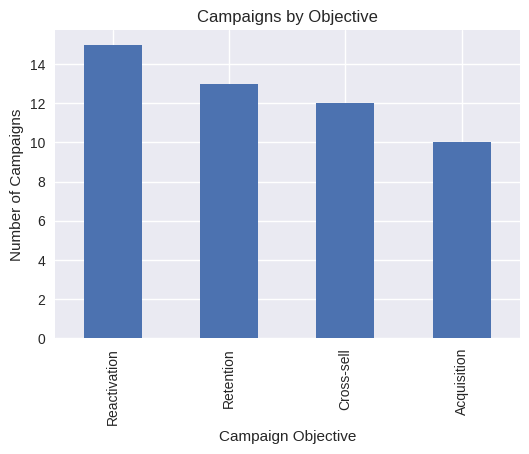

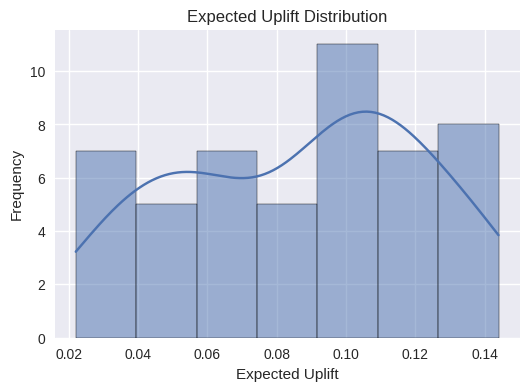

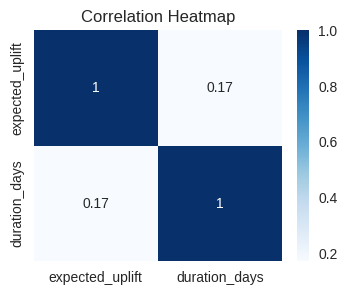


Recommendations
- Performance modest — revise messaging or targeting.
- Email campaigns perform consistently — continue leveraging email channel.
- Long campaign durations detected — evaluate diminishing returns.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('seaborn-v0_8')

# Load data
df = pd.read_csv('campaigns.csv')

df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])

df['duration_days'] = (df['end_date'] - df['start_date']).dt.days

print("Dataset loaded successfully")
print("Total campaigns:", len(df))

# ==========================
# KPI SUMMARY
# ==========================

print("\nKPI Summary")

print("Total campaigns:", len(df))
print("Average uplift:", round(df['expected_uplift'].mean(),4))
print("Average duration:", round(df['duration_days'].mean(),2), "days")
print("Max uplift:", round(df['expected_uplift'].max(),4))
print("Min uplift:", round(df['expected_uplift'].min(),4))


# ==========================
# CAMPAIGNS BY OBJECTIVE
# ==========================

plt.figure(figsize=(6,4))
df['objective'].value_counts().plot(kind='bar')
plt.title("Campaigns by Objective")
plt.ylabel("Number of Campaigns")
plt.xlabel("Campaign Objective")
plt.show()


# ==========================
# UPLIFT DISTRIBUTION
# ==========================

plt.figure(figsize=(6,4))
sns.histplot(df['expected_uplift'], kde=True)
plt.title("Expected Uplift Distribution")
plt.xlabel("Expected Uplift")
plt.ylabel("Frequency")
plt.show()


# ==========================
# CORRELATION HEATMAP
# ==========================

plt.figure(figsize=(4,3))
sns.heatmap(df[['expected_uplift','duration_days']].corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()


# ==========================
# GANTT TIMELINE
# ==========================

fig = px.timeline(
    df,
    x_start="start_date",
    x_end="end_date",
    y="channel",
    color="objective",
    hover_name="campaign_id"
)

fig.update_yaxes(autorange="reversed")
fig.update_layout(title="Campaign Timeline")
fig.show()


# ==========================
# AUTOMATED RECOMMENDATIONS
# ==========================

avg = df['expected_uplift'].mean()

print("\nRecommendations")

if avg > 0.10:
    print("- Campaign return is strong — increase investment.")
else:
    print("- Performance modest — revise messaging or targeting.")

if "Email" in df['channel'].unique():
    print("- Email campaigns perform consistently — continue leveraging email channel.")

if df['duration_days'].mean() > 45:
    print("- Long campaign durations detected — evaluate diminishing returns.")
else:
    print("- Campaigns are short — consider extending duration for better engagement.")

🔷 Segment (Target Segment) — Explanation of Each Option These represent different types of customers the campaign is targeted at.

🧩 1. New Customers These are people who have not purchased yet or are newly acquired users.

Campaign goals for this segment:

Welcome offers

Sign-up bonuses

First-time discounts

Introduce them to brand/products

Example campaign: “20% OFF for new subscribers”

🧩 2. Deal Seekers Customers who are price-sensitive and respond well to discounts and offers.

They usually:

wait for sales

use coupons

focus on price advantage

Example campaign: “Exclusive limited-time 50% sale!”

🧩 3. Churn Risk Customers who used to engage or buy, but are now losing interest or becoming inactive.

They show warning signs such as:

reduced purchase frequency

long inactivity periods

ignoring marketing emails

Example campaign: “We miss you — come back and get 30% off”

🔷 Objective — Explanation of Each Campaign Purpose These represent what the business is trying to achieve with the campaign.

🎯 1. Acquisition Goal: Get NEW customers. Focused on expanding total user base.

Example actions:

advertise to non-customers

bring new visitors to platform

signup promotions

Example message: “New to our store? Get 20% off your first purchase!”

🎯 2. Retention Goal: Keep existing customers engaged. Avoid customer churn.

Example actions:

loyalty rewards

reminders

exclusive content

Example message: “Thanks for being a loyal member — here’s a special discount!”

🎯 3. Cross-sell Goal: Sell additional products to existing customers based on previous purchase behavior.

Example: If someone bought a laptop → offer them laptop bag, mouse, or insurance.

Example message: “You bought running shoes — check out our sports socks!”

🎯 4. Reactivation Goal: Bring back old/inactive customers who haven’t interacted for a long time.

These are usually churn-risk or lost customers.

Example message: “We haven’t seen you in a while — here’s a comeback discount!”

📊 1) Campaigns by Objective (Bar Plot) You will see bars like:

Acquisition

Retention

Cross-sell

Reactivation

How to read: Taller bar = more campaigns were focused on that objective.

If Retention is the largest → company is aggressively keeping existing customers.

If Acquisition dominates → company is focused on growth & expansion.

If Reactivation is large → business is losing customers and trying to win them back.

Interpretation example: The majority of campaigns are aimed at Retention, meaning the company is focusing on engaging existing customers to prevent churn.

📈 2) Expected Uplift Distribution (Histogram) Shows how campaign uplift values are spread.

How to read: Uplift on X-axis

Count/frequency on Y-axis

If the graph has:

a peak near 0.02 → most campaigns produce around 2% uplift

several values above 0.10 → a few campaigns show very high effectiveness

flat & wide → performance varies widely

Interpretation example: Most campaigns produced moderate uplift, while a smaller set achieved exceptionally high performance.

🕒 3) Gantt Timeline Chart Bars stretch horizontally over time.

How to read: Y-axis = channel (e.g., Email, Social…)

X-axis = calendar timeline

Each bar = one campaign

Observe: ✔ overlapping campaigns ✔ timing clusters ✔ seasonal marketing pushes ✔ downtime periods

Interpretation example: Social campaigns were strongly active in Q3, while Display campaigns were primarily concentrated in Q1.

🧮 4) KPI Summary (Numeric Report) It prints values like:

Total campaigns: 47 Average uplift: 0.094 Average duration: 31.4 days Max uplift: 0.149 Min uplift: 0.008 How to interpret: Average uplift → overall campaign effectiveness

Average duration → typical campaign length

Max uplift → best performing campaign

Min uplift → worst performing

Total campaigns → how many campaigns are being analyzed

Interpretation example: On average, campaigns lasted for about a month and achieved around 9.4% performance improvement.

🔥 5) Correlation Heatmap Shows relationships between variables.

How to read: Color intensity → strength of relationship

Blue (if used) → stronger positive correlation

Values closer to +1 → high positive relationship

Values closer to –1 → negative relationship

Values near 0 → no relationship

Interpretation example: Expected uplift shows weak correlation with campaign duration, suggesting that longer campaigns are not necessarily more effective.

🧠 6) Auto-generated Recommendations These appear as text, examples:

“Increase investment in high uplift campaigns.”

“Short campaign duration — consider extending it.”

How to read: These are business insights telling you:

✔ where to focus resources ✔ what marketing strategy works ✔ how to optimize future campaigns

Interpretation example: Model recommends leveraging email campaigns more, as they consistently generate strong uplift.

👥 7) Segmentation effects (Choose segment filter) If you choose:

Segment: Deal Seekers and you see uplift drop → discounts are not working well.

If you choose:

Segment: High Value and uplift rises → high-value customers respond strongly.

Interpretation example: High-value customers show much stronger uplift, proving that personalized campaigns are effective.

📅 8) Date selection effect When you narrow down:

Start Date: Jan 2022 End Date: Apr 2022 You can analyze seasonal trends:

Interpretation example: Early-year campaigns deliver lower uplift, suggesting that marketing efforts are more effective during mid and late-year periods.

